In [9]:
from src.game_utils import TicTacToeGame


In [10]:
player_1 = "src/models/Alice.pt"
player_2 = "src/models/Bob.pt"
player_1_name = "Alice" # by default it is "Player 1 [X]"
player_2_name = "Bob" # by default it is "Player 2 [O]"
game = TicTacToeGame(
    player_1, \
    player_2, \
    player_1_name=player_1_name, \
    player_2_name=player_2_name
)
result = game.play(visualise=True)


Game Over: Bob [O] won!
+----+-----+-----+-----+
|    | 1   | 2   | 3   |
+====+=====+=====+=====+
| A  | O   | X   | O   |
+----+-----+-----+-----+
| B  | X   | X   | O   |
+----+-----+-----+-----+
| C  | X   | O   | O   |
+----+-----+-----+-----+


Did you detect any strategy? Who do you think plays well? Find out!

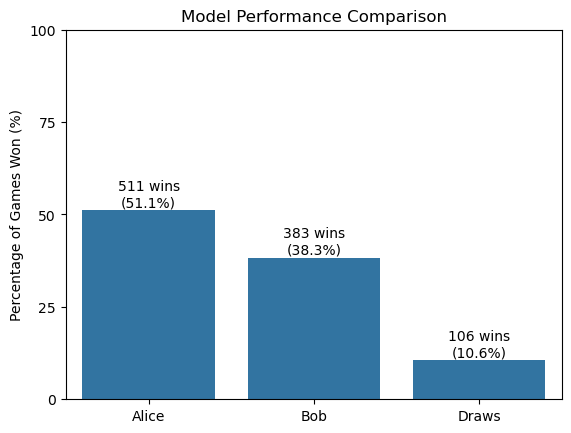

In [11]:
from src.game_utils import evaluate_models, plot_histogram

# Evaluate the models
num_games = 1000
results = evaluate_models(player_1, player_2, num_games)
# plot the histogram of results
plot_histogram(results, player_1_name, player_2_name)

In [1]:
# Now you play! 
from src.game_utils import User_vs_Computer
your_name = "ENTERYOURNAME"
opponent = "Alice" # or "Bob"
game = User_vs_Computer(your_name, opponent=opponent)

Game Over!
+----+-----+-----+-----+
|    | 1   | 2   | 3   |
+====+=====+=====+=====+
| A  | X   |     | O   |
+----+-----+-----+-----+
| B  | X   | O   | X   |
+----+-----+-----+-----+
| C  | O   |     | O   |
+----+-----+-----+-----+
Alice [O] wins!


Think you can teach Alice or Bob how to play better? Well, all you need is to show them how to play the game. Play against either of them and let us find a way to teach them better. 

In [13]:
from src.train_game_utils import generate_data_from_user_input

generated_data = generate_data_from_user_input(n_games=10, opponent="Alice")

Game Over!
+----+-----+-----+-----+
|    | 1   | 2   | 3   |
+====+=====+=====+=====+
| A  |     | X   |     |
+----+-----+-----+-----+
| B  |     | X   | O   |
+----+-----+-----+-----+
| C  | O   | X   |     |
+----+-----+-----+-----+
username [X] wins!


In [14]:
generated_data

{'game_1': [(array([ 0,  0,  0,  0,  1,  0, -1,  0,  0]), 4),
  (array([ 1,  0,  0, -1,  1,  0, -1,  0,  0]), 0),
  (array([ 1, -1,  0, -1,  1,  0, -1,  0,  1]), 8)],
 'game_2': [(array([-1,  0,  0,  0,  1,  0,  0,  0,  0]), 4),
  (array([-1,  1, -1,  0,  1,  0,  0,  0,  0]), 1),
  (array([-1,  1, -1,  0,  1,  0,  0,  1, -1]), 7)],
 'game_3': [(array([ 0,  0, -1,  0,  1,  0,  0,  0,  0]), 4),
  (array([ 0,  0, -1,  0,  1,  1,  0,  0, -1]), 5),
  (array([ 0,  0, -1,  1,  1,  1, -1,  0, -1]), 3)],
 'game_4': [(array([ 0,  0,  0,  0,  1,  0,  0,  0, -1]), 4),
  (array([ 0,  0,  1, -1,  1,  0,  0,  0, -1]), 2),
  (array([ 0, -1,  1, -1,  1,  0,  1,  0, -1]), 6)],
 'game_5': [(array([1, 0, 0, 0, 0, 0, 0, 0, 0]), 0),
  (array([ 1, -1,  0,  0,  0,  0,  0,  0,  1]), 8),
  (array([ 1, -1,  0,  0, -1,  0,  1,  0,  1]), 6),
  (array([ 1, -1, -1,  1, -1,  0,  1,  0,  1]), 3)],
 'game_6': [(array([ 1,  0,  0,  0,  0,  0, -1,  0,  0]), 0),
  (array([ 1,  0,  0, -1,  0,  0, -1,  0,  1]), 8),
  (array

In [24]:
import os 
from src.train_game_utils import load_model_from_path, train_model, define_model

# From the generated data, split into X and Y 
X_input = []
Y_output = []

for game in generated_data.keys():
    user_input = generated_data[game]
    for move in user_input:
        X_input.append(move[0])
        Y_output.append(move[1])

print(f"Length of X_input: {len(X_input)}")
print(f"Length of Y_output: {len(Y_output)}")

#Alice_model = load_model_from_path("src/models/Alice.pt")
new_model = define_model()
# Train the model on the generated data
retrained = train_model(new_model, X_input, Y_output, num_epochs=100)

# Save the trained model
import torch 
save_folder = "src/models/retrained_models/"
os.makedirs(save_folder, exist_ok=True)
new_model_name = "retrain_3.pt"
trained_model_path = os.path.join(save_folder, new_model_name)
torch.save(retrained.state_dict(), trained_model_path)

print(f"Model retrained and saved at: {trained_model_path}")


Length of X_input: 32
Length of Y_output: 32
Epoch 1/100, Loss: 1.7186, Val Loss: 2.1981
Epoch 2/100, Loss: 1.7165, Val Loss: 2.1975
Epoch 3/100, Loss: 1.7157, Val Loss: 2.1969
Epoch 4/100, Loss: 1.7154, Val Loss: 2.1962
Epoch 5/100, Loss: 1.7140, Val Loss: 2.1955
Epoch 6/100, Loss: 1.7138, Val Loss: 2.1947
Epoch 7/100, Loss: 1.7109, Val Loss: 2.1940
Epoch 8/100, Loss: 1.7098, Val Loss: 2.1932
Epoch 9/100, Loss: 1.7069, Val Loss: 2.1923
Epoch 10/100, Loss: 1.7076, Val Loss: 2.1914
Epoch 11/100, Loss: 1.7060, Val Loss: 2.1906
Epoch 12/100, Loss: 1.7051, Val Loss: 2.1896
Epoch 13/100, Loss: 1.7054, Val Loss: 2.1887
Epoch 14/100, Loss: 1.7009, Val Loss: 2.1876
Epoch 15/100, Loss: 1.6997, Val Loss: 2.1865
Epoch 16/100, Loss: 1.6981, Val Loss: 2.1854
Epoch 17/100, Loss: 1.6964, Val Loss: 2.1842
Epoch 18/100, Loss: 1.6929, Val Loss: 2.1829
Epoch 19/100, Loss: 1.6921, Val Loss: 2.1815
Epoch 20/100, Loss: 1.6887, Val Loss: 2.1798
Epoch 21/100, Loss: 1.6906, Val Loss: 2.1781
Epoch 22/100, Loss:

Is it better? 

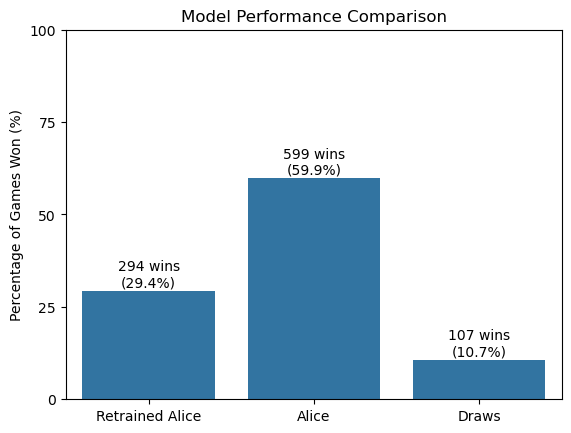

In [26]:
results_new = evaluate_models(trained_model_path, player_1, num_games)
plot_histogram(results_new, "Retrained Alice", player_1_name)

In [28]:
os.uname().nodename

'Aloks-MacBook-Air.local'

In [1]:
from src.utils import upload_file_to_dropbox

filepath = "/Users/alokbharadwaj/dev/ai4nanobiology/week_1/src/models/retrained_models/retrain_3.pt"

dropbox_link = upload_file_to_dropbox(filepath)

BadInputError: BadInputError('1c6b4c56fa2c47f0a0fbc11169d3d6fe', 'Error in call to API function "files/upload": Your app (ID: 6642435) is not permitted to access this endpoint because it does not have the required scope \'files.content.write\'. The owner of the app can enable the scope for the app using the Permissions tab on the App Console.')